In [15]:
import numpy as np
from matplotlib import pyplot as plt


# generate grid
xmin = 0
xmax = 10
nx = 101
# dx = (xmax - xmin)/(nx-1)

mumin = 0
mumax = 10.
nmu = 101

x,dx = np.linspace(xmin, xmax, nx, retstep=True)
mu,dmu = np.linspace(mumin, mumax, nmu, retstep=True)

mugrid, xgrid = np.meshgrid(mu, x)

psi_grid = 20.-np.sqrt((xgrid - 5)**2 + (mugrid-5)**2)

In [16]:
def sor(a,b,c,d,e,f,psi_grid,MAXITS,imax,jmax,w,tol,rjac):
    # anormf=0.0
    # anormf=np.sum(np.abs(f))
    w = 1.0

    for n in range(0,MAXITS):
            # print(f"iter = {n} psi[1,10] = {psi_grid[1,10]}")
            anorm = 0.0
            isw = 1
 
            for ipass in range(1,3):

                jsw=isw

                # Relaxation iteration procedure to update psi(x,y):
                for i in range(0,imax):
                    
                    for j in range(jsw-1,jmax,2):

                        residual = 0.0

                        # Calculate residuals as per SOR algorithm equation 19.5.28 Press et al 1992 and Notebook 04 p94
                        if(i<imax-1):
                            residual+=a[i,j]*psi_grid[i+1,j]

                        if(i>0):
                            residual+=b[i,j]*psi_grid[i-1,j]

                        if(j<jmax-1):
                            residual+=c[i,j]*psi_grid[i,j+1]

                        if(j>0):
                            residual+=d[i,j]*psi_grid[i,j-1]

                        residual+=e[i,j]*psi_grid[i,j]
                        
                        residual-=f[i,j]

                        anorm+=np.abs(residual)

#                         if((n < 20)):
#                             if(i < 2):
#                                 if((j < jmax-1)):
#                                     print(f"n={n} ({i}, {j}) psi={psi_grid[i,j]:0.6f} w*resid/e_ij = {w*residual/e[i,j]:0.6f} a ={a[i,j]*psi_grid[i+1,j]:0.6f} b={b[i,j]:0.6f} c={c[i,j]*psi_grid[i,j+1]:0.6f}, d={d[i,j]:0.6f} e={e[i,j]*psi_grid[i,j]:0.6f} f={f[i,j]}, r = {residual:0.6f}")
#                                     # print(f"n={n} ({i}, {j}) psi={psi_grid[i,j]} w*resid/e_ij = {w*residual/e[i,j]} resid={residual}, {a[i,j]*psi_grid[i+1,j] +c[i,j]*psi_grid[i,j+1] + e[i,j]*psi_grid[i,j] - f[i,j]}")
#                             else:
#                                 continue
                        

                        psi_grid[i,j] -= w*residual/e[i,j]

                    jsw = 3-jsw

                isw = 3 - isw
                
                if((n==1) & (ipass==1)):
                    w = 1.0/(1.0-0.5*rjac*rjac)
                else:
                    w = 1.0/(1.0-0.25*rjac*rjac*w)

            # print("iter = %d anorm = %lg"%(n,anorm/anormf))
                
            if(anorm < tol):
                # print("Finished")
                break
    return psi_grid

In [17]:
# boundary conditions (0 = derivative fixed, 1 = fixed BC)
BCMUMIN = 1
BCMUMAX = 1
BCXMIN = 1
BCXMAX = 0

# initial boundary temperatures
T_bottom = 50
T_top = 8
T_left = 25
T_right = 15
psi_grid[0,:] = T_bottom
psi_grid[-1,:] = T_top
psi_grid[:,0] = T_left
psi_grid[:,-1] = T_right

# generate coefficient arrays
M = nx - BCXMIN - BCXMAX
N = nmu - BCMUMIN - BCMUMAX
a = np.ones((M,N))*1./dx/dx
b = np.ones((M,N))*1./dx/dx
c = np.ones((M,N))*1./dmu/dmu
d = np.ones((M,N))*1./dx/dx
e = -2.*(1./dx/dx + 1./dmu/dmu)*np.ones((M,N))

# apply BCs to coefficient arrays
# prevent referencing outside arrays
# a[-1,:] = 0.
# b[0,:] = 0.
# c[:,-1] = 0.
# d[:,0] = 0.

# derivative BCs
if(BCXMIN == 0):
    a[0,:] = 2.*a[0,:]
if(BCXMAX == 0):
    b[-1,:] = 2.*b[-1,:]
if(BCMUMIN == 0):
    c[:,0] = 2.*c[:,0]
if(BCMUMIN == 0):
    d[:,-1] = 2.*d[:,-1]

psi_grid_orig = np.copy(psi_grid)

In [18]:
# generate f
f = np.ones_like(psi_grid)
f0 = 2.
x0 = 3.
mu0 = 5.5
sigma_x = 1
sigma_mu = 2.2
for i in range(nx):
    for j in range(nmu):
        f[i,j] = 0.#-f0*np.exp(-(xgrid[i,j] - x0)**2/2/sigma_x**2)*np.exp(-(mugrid[i,j] - mu0)**2/2/sigma_mu**2)


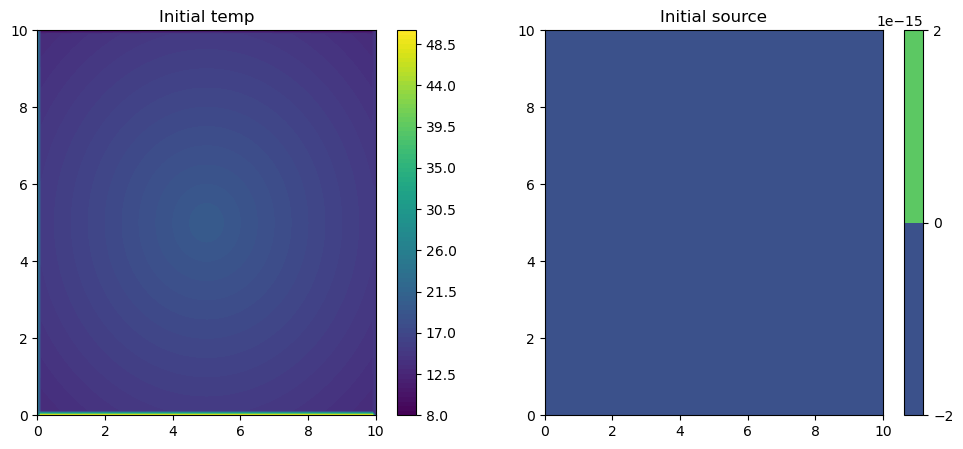

In [19]:
fig,(axpsi, axf) = plt.subplots(1,2, figsize = (12,5))
cbpsi = axpsi.contourf(mugrid,xgrid, psi_grid, levels=100)
cbf = axf.contourf(mugrid,xgrid, -f, levels=100)
fig.colorbar(cbpsi, ax = axpsi)
fig.colorbar(cbf, ax = axf)
axpsi.set(title="Initial temp")
axf.set(title="Initial source")
plt.show()

In [20]:
# form poisson arrays
psi_poisson = psi_grid[BCXMIN:nx-BCXMAX, BCMUMIN:nmu-BCMUMAX]
f_poisson = f[BCXMIN:nx-BCXMAX, BCMUMIN:nmu-BCMUMAX]

# apply fixed BCs to f array
# i = 0, re-add bij*psi_{i-1,j} to f_poisson
if(BCXMIN==1):
    f_poisson[0,:] -= b[0,:]*psi_grid[0,BCMUMIN:nmu-BCMUMAX]
if(BCXMAX==1):
    f_poisson[-1,:] -= a[-1,:]*psi_grid[-1,BCMUMIN:nmu-BCMUMAX]
if(BCMUMIN==1):
    f_poisson[:,0] -= d[:,0]*psi_grid[BCXMIN:nx-BCXMAX,0]
if(BCMUMAX==1):
    f_poisson[:,-1] -= c[:,-1]*psi_grid[BCXMIN:nx-BCXMAX,-1]

In [21]:
# form SOR
rjac = 1. - np.pi**2./nx/nmu
psi_poisson_sor = sor(a,b,c,d,e,f_poisson, psi_poisson, 10000, M,N,1., 1.e-2, rjac)

In [22]:
# place back into main array
psi_grid[BCXMIN:nx-BCXMAX, BCMUMIN:nmu-BCMUMAX] = np.copy(psi_poisson_sor)

Tb = 50.00(50) Tt = 24.13(8) Tl = 25.00(25) Tr = 15.00(15)


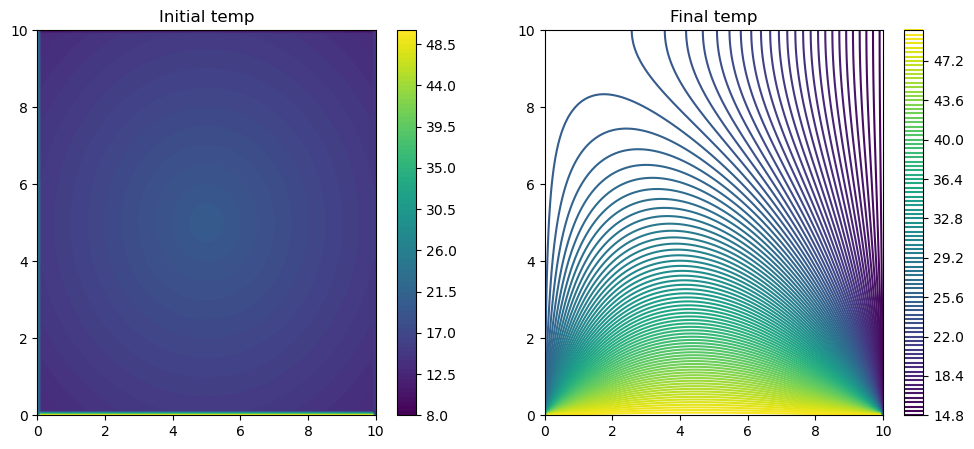

In [23]:
# plot
fig,(axpsi, axf) = plt.subplots(1,2, figsize = (12,5))
cbpsi = axpsi.contourf(mugrid,xgrid, psi_grid_orig, levels=100)
cbf = axf.contour(mugrid,xgrid, psi_grid, levels=100)
fig.colorbar(cbpsi, ax = axpsi)
fig.colorbar(cbf, ax = axf)
axpsi.set(title="Initial temp")
axf.set(title="Final temp")
print(f"Tb = {psi_grid[0,40]:0.2f}({T_bottom}) Tt = {psi_grid[-1,40]:0.2f}({T_top}) Tl = {psi_grid[40,0]:0.2f}({T_left}) Tr = {psi_grid[40,-1]:0.2f}({T_right})")
plt.show()